
# Día de $\pi$: estimar $\pi$ con la aguja de Buffon

Este notebook muestra una forma clásica, elegante y muy divulgativa de **estimar $\pi$** con un experimento aleatorio.

La idea es lanzar muchos **palitos** sobre una hoja con **líneas paralelas**.  
La fracción de palitos que cruzan alguna línea permite estimar el valor de $\pi$.

## Idea matemática

Si la longitud del palito es $L$ y la distancia entre líneas es $d$, con $L \le d$, entonces

$$
P(\text{cruce}) = \frac{2L}{\pi d}.
$$

De ahí sale la estimación

$$
\pi \approx \frac{2L}{d\,\hat p},
$$

donde $\hat p$ es la proporción observada de palitos que cruzan una línea.

En este notebook usaremos el caso simple $L=d=1$, así que

$$
\pi \approx \frac{2}{\hat p}.
$$

---

## ¿Qué encontrarás aquí?

1. Una simulación básica del experimento.  
2. Una visualización de los palitos lanzados.  
3. Una gráfica de convergencia de la estimación de $\pi$.  
4. Una celda opcional con control interactivo del número de palitos.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True



## 1. Funciones del experimento

La primera función simula los ángulos y posiciones de los palitos para estimar $\pi$.  
La segunda genera una visualización del experimento sobre una “hoja” con líneas paralelas.


In [2]:

def buffon_pi(n=1000, L=1.0, d=1.0, seed=None):
    '''
    Simula el experimento de la aguja de Buffon.

    Parámetros
    ----------
    n : int
        Número de palitos lanzados.
    L : float
        Longitud del palito.
    d : float
        Distancia entre líneas paralelas.
    seed : int o None
        Semilla aleatoria para reproducibilidad.

    Retorna
    -------
    pi_est : float
        Estimación de pi.
    p_hat : float
        Proporción de cruces observada.
    crosses : np.ndarray
        Vector booleano indicando si cada palito cruza una línea.
    theta : np.ndarray
        Ángulos simulados.
    y : np.ndarray
        Distancias del centro del palito a la línea más cercana.
    '''
    if L > d:
        raise ValueError("Esta versión asume L <= d.")
    if n <= 0:
        raise ValueError("n debe ser positivo.")

    rng = np.random.default_rng(seed)

    theta = rng.uniform(0, np.pi / 2, size=n)
    y = rng.uniform(0, d / 2, size=n)

    crosses = y <= (L / 2) * np.sin(theta)
    p_hat = crosses.mean()

    pi_est = np.nan if p_hat == 0 else (2 * L) / (d * p_hat)
    return pi_est, p_hat, crosses, theta, y


def draw_buffon_sheet(n=200, L=1.0, d=1.0, width=8, height=6, seed=None):
    '''
    Dibuja una hoja con líneas paralelas y los palitos lanzados.
    Los palitos que cruzan alguna línea se muestran en un color distinto.
    '''
    if L > d:
        raise ValueError("Esta visualización asume L <= d.")

    rng = np.random.default_rng(seed)

    cx = rng.uniform(L/2, width - L/2, size=n)
    cy = rng.uniform(L/2, height - L/2, size=n)
    theta = rng.uniform(0, np.pi, size=n)

    dx = (L / 2) * np.cos(theta)
    dy = (L / 2) * np.sin(theta)

    x1, x2 = cx - dx, cx + dx
    y1, y2 = cy - dy, cy + dy

    crosses = np.floor(y1 / d) != np.floor(y2 / d)

    fig, ax = plt.subplots(figsize=(9, 6))

    for yline in np.arange(0, height + d, d):
        ax.hlines(yline, 0, width, linewidth=1)

    for i in range(n):
        ax.plot(
            [x1[i], x2[i]],
            [y1[i], y2[i]],
            linewidth=1.5,
            alpha=0.85,
            color="tab:red" if crosses[i] else "tab:blue"
        )

    p_hat = crosses.mean()
    pi_est = np.nan if p_hat == 0 else (2 * L) / (d * p_hat)

    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect("equal")
    ax.set_title(
        f"Experimento de Buffon | n = {n} | cruces = {crosses.sum()} | π estimado = {pi_est:.5f}"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.savefig("BuffonPi.png",dpi=300,bbox_inches='tight')
    plt.show()

    return pi_est, crosses.sum()


## 2. Un experimento simple

In [3]:

pi_est, p_hat, crosses, theta, y = buffon_pi(n=5000, L=1.0, d=1.0, seed=42)

print(f"Proporción de cruces: {p_hat:.5f}")
print(f"Estimación de pi:     {pi_est:.6f}")
print(f"Valor real de pi:     {np.pi:.6f}")
print(f"Error absoluto:       {abs(pi_est - np.pi):.6f}")


Proporción de cruces: 0.63700
Estimación de pi:     3.139717
Valor real de pi:     3.141593
Error absoluto:       0.001875


## 3. Visualización de la hoja con palitos

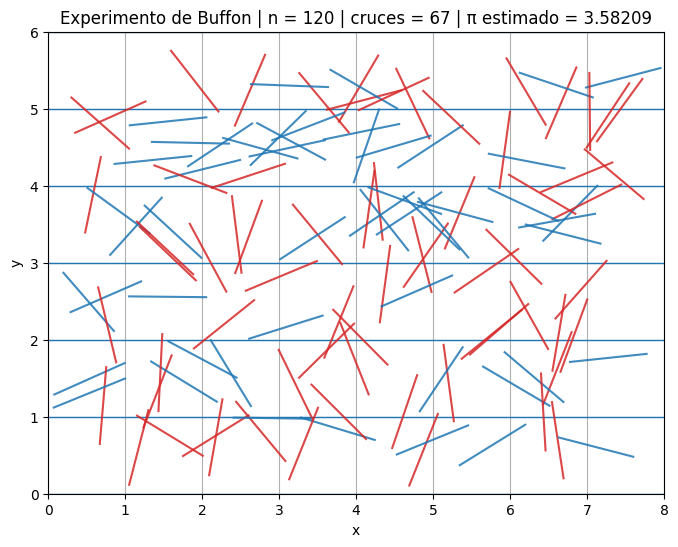

In [4]:

draw_buffon_sheet(n=120, L=1.0, d=1.0, width=8, height=6, seed=7);



## 4. Cómo mejora la estimación al lanzar más palitos

En promedio, mientras más palitos se lanzan, la estimación suele estabilizarse alrededor de $\pi$.  
Como es un experimento aleatorio, habrá fluctuaciones, pero la tendencia general es de convergencia.


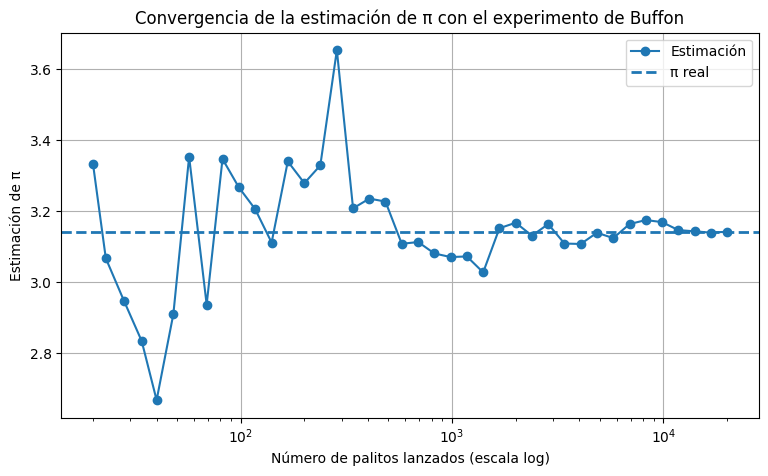

In [5]:

Ns = np.unique(np.geomspace(20, 20000, 40).astype(int))
estimates = []

for n in Ns:
    pi_est, _, _, _, _ = buffon_pi(n=n, L=1.0, d=1.0, seed=123)
    estimates.append(pi_est)

plt.figure(figsize=(9, 5))
plt.plot(Ns, estimates, marker="o", linewidth=1.5, label="Estimación")
plt.axhline(np.pi, linestyle="--", linewidth=2, label="π real")
plt.xscale("log")
plt.xlabel("Número de palitos lanzados (escala log)")
plt.ylabel("Estimación de π")
plt.title("Convergencia de la estimación de π con el experimento de Buffon")
plt.legend()
plt.savefig("ValuesPi.png",dpi=300,bbox_inches='tight')
plt.show()



## 5. Variabilidad entre repeticiones

Aunque se use el mismo número de palitos, distintas repeticiones del experimento pueden dar estimaciones algo distintas.  
Eso permite hablar en tu blog sobre **azar, variabilidad, error muestral** y **ley de los grandes números**.


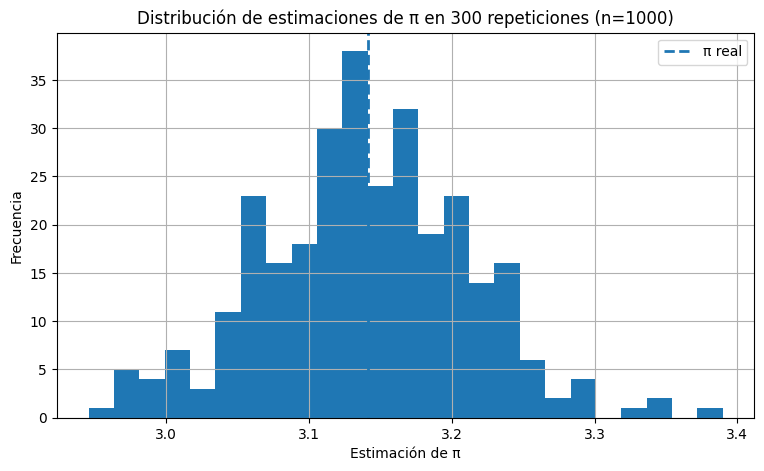

Promedio de las estimaciones: 3.13977
Desviación estándar:          0.07276


In [6]:

n = 1000
reps = 300
vals = []

for s in range(reps):
    pi_est, _, _, _, _ = buffon_pi(n=n, L=1.0, d=1.0, seed=s)
    vals.append(pi_est)

plt.figure(figsize=(9, 5))
plt.hist(vals, bins=25)
plt.axvline(np.pi, linestyle="--", linewidth=2, label="π real")
plt.xlabel("Estimación de π")
plt.ylabel("Frecuencia")
plt.title(f"Distribución de estimaciones de π en {reps} repeticiones (n={n})")
plt.legend()
plt.savefig("DistriPi.png",dpi=300,bbox_inches='tight')
plt.show()

print(f"Promedio de las estimaciones: {np.mean(vals):.5f}")
print(f"Desviación estándar:          {np.std(vals, ddof=1):.5f}")



## 6. Celda opcional: control interactivo del número de palitos

Esta parte intenta usar `ipywidgets` para agregar un deslizador que controle el número de palitos.  
Si no lo tienes instalado, el notebook seguirá funcionando y te mostrará cómo instalarlo.

En muchos entornos basta con:

```bash
pip install ipywidgets
```

o, en Anaconda:

```bash
conda install -c conda-forge ipywidgets
```


In [7]:

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    output = widgets.Output()

    slider = widgets.IntSlider(
        value=200,
        min=20,
        max=2000,
        step=20,
        description="Palitos:",
        continuous_update=False
    )

    seed_box = widgets.IntText(value=10, description="Semilla:")

    def update_plot(change=None):
        with output:
            clear_output(wait=True)
            draw_buffon_sheet(
                n=slider.value,
                L=1.0,
                d=1.0,
                width=8,
                height=6,
                seed=seed_box.value
            )

    slider.observe(update_plot, names="value")
    seed_box.observe(update_plot, names="value")

    display(widgets.HBox([slider, seed_box]))
    display(output)
    update_plot()

except ImportError:
    print("ipywidgets no está instalado en este entorno.")
    print("Puedes instalarlo con: pip install ipywidgets")


Output()


## **Estimar $\pi$ lanzando palitos: azar, geometría y simulación computacional**

### Hilo narrativo
- El Día de $\pi$ suele celebrarse con fórmulas y curiosidades, pero también puede celebrarse con experimentos.
- Lo fascinante del experimento de Buffon es que una constante geométrica como $\pi$ aparece a partir del azar.
- El resultado no sale “perfecto” con pocos lanzamientos, y eso abre una conversación sobre incertidumbre y convergencia.
- La simulación computacional permite repetir miles de veces el experimento en segundos.
- Así, el problema conecta probabilidad, geometría, estadística y computación en una sola actividad.

### Cierre
**A veces $\pi$ no aparece dibujando círculos, sino dejando caer palitos sobre una hoja rayada y observando cómo el azar revela estructura.**


In [8]:
!pip3 install plotly --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [9]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path

def buffon_segments_for_plot(n=200, L=1.0, d=1.0, width=8, height=6, seed=10):
    rng = np.random.default_rng(seed)

    cx = rng.uniform(L/2, width - L/2, size=n)
    cy = rng.uniform(L/2, height - L/2, size=n)
    theta = rng.uniform(0, np.pi, size=n)

    dx = (L / 2) * np.cos(theta)
    dy = (L / 2) * np.sin(theta)

    x1, x2 = cx - dx, cx + dx
    y1, y2 = cy - dy, cy + dy

    crosses = np.floor(y1 / d) != np.floor(y2 / d)
    p_hat = crosses.mean()
    pi_est = np.nan if p_hat == 0 else (2 * L) / (d * p_hat)

    return x1, x2, y1, y2, crosses, pi_est

def make_buffon_plotly_html(
    n_values=(20, 50, 100, 200, 500, 1000, 2000, 3500, 5000, 7500, 10000, 12500, 15000, 17500, 20000, 25000),
    L=1.0, d=1.0, width=8, height=6, seed=10,
    outfile="buffon_embed.html"
):
    frames = []
    slider_steps = []

    # Líneas de fondo
    shapes_base = []
    for yline in np.arange(0, height + d, d):
        shapes_base.append({
            "type": "line",
            "x0": 0, "x1": width,
            "y0": float(yline), "y1": float(yline),
            "line": {"width": 1}
        })

    # Figura inicial
    n0 = n_values[0]
    x1, x2, y1, y2, crosses, pi_est = buffon_segments_for_plot(
        n=n0, L=L, d=d, width=width, height=height, seed=seed
    )

    fig = go.Figure()

    # cruces
    fig.add_trace(go.Scatter(
        x=np.ravel(np.column_stack([x1[crosses], x2[crosses], np.full(crosses.sum(), np.nan)])),
        y=np.ravel(np.column_stack([y1[crosses], y2[crosses], np.full(crosses.sum(), np.nan)])),
        mode="lines",
        name="Cruzan",
        line=dict(width=2, color="red"),
        hoverinfo="skip"
    ))

    # no cruces
    fig.add_trace(go.Scatter(
        x=np.ravel(np.column_stack([x1[~crosses], x2[~crosses], np.full((~crosses).sum(), np.nan)])),
        y=np.ravel(np.column_stack([y1[~crosses], y2[~crosses], np.full((~crosses).sum(), np.nan)])),
        mode="lines",
        name="No cruzan",
        line=dict(width=2, color="royalblue"),
        hoverinfo="skip"
    ))

    for n in n_values:
        x1, x2, y1, y2, crosses, pi_est = buffon_segments_for_plot(
            n=n, L=L, d=d, width=width, height=height, seed=seed
        )

        red_x = np.ravel(np.column_stack([x1[crosses], x2[crosses], np.full(crosses.sum(), np.nan)]))
        red_y = np.ravel(np.column_stack([y1[crosses], y2[crosses], np.full(crosses.sum(), np.nan)]))

        blue_x = np.ravel(np.column_stack([x1[~crosses], x2[~crosses], np.full((~crosses).sum(), np.nan)]))
        blue_y = np.ravel(np.column_stack([y1[~crosses], y2[~crosses], np.full((~crosses).sum(), np.nan)]))

        title = f"Experimento de Buffon | n = {n} | cruces = {crosses.sum()} | π estimado = {pi_est:.5f}"

        frames.append(go.Frame(
            name=str(n),
            data=[
                go.Scatter(x=red_x, y=red_y),
                go.Scatter(x=blue_x, y=blue_y),
            ],
            layout=go.Layout(title=title)
        ))

        slider_steps.append({
            "args": [[str(n)], {"frame": {"duration": 0, "redraw": True},
                                "mode": "immediate",
                                "transition": {"duration": 0}}],
            "label": str(n),
            "method": "animate"
        })

    fig.frames = frames

    fig.update_layout(
        title=f"Experimento de Buffon | n = {n0}",
        width=900,
        height=650,
        xaxis=dict(range=[0, width], title="x"),
        yaxis=dict(range=[0, height], title="y", scaleanchor="x", scaleratio=1),
        shapes=shapes_base,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Número de palitos: "},
            "pad": {"t": 30},
            "steps": slider_steps
        }],
        margin=dict(l=40, r=40, t=70, b=40)
    )

    # HTML incrustable
    html = fig.to_html(full_html=False, include_plotlyjs="cdn")
    Path(outfile).write_text(html, encoding="utf-8")
    return outfile

make_buffon_plotly_html()

'buffon_embed.html'